In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, underride, configure_plot_style, AIBM_COLORS, code_to_who_country, code_to_wef_country

configure_plot_style()

In [3]:
# Function to format numbers to 3 significant digits
def format_sig_figs(x):
    """Format a number to 3 significant digits."""
    if pd.isna(x):
        return x
    # Convert to float and format to 3 significant digits
    return float(f'{x:.3g}')

# Format numeric columns to 3 significant digits before writing to HTML
def format_table_sig_figs(df):
    """Format all numeric columns in a DataFrame to 3 significant digits."""
    df_formatted = df.copy()
    for col in df_formatted.columns:
        if df_formatted[col].dtype in ['float64', 'float32', 'int64', 'int32']:
            df_formatted[col] = df_formatted[col].apply(format_sig_figs)
    return df_formatted

## Load Saved Data

In [4]:
# Code to read the saved data back from HDF5 file
hdf_file = '../data/hale_analysis_data.h5'

# Read data back
with pd.HDFStore(hdf_file, mode='r') as store:
    predictors_full = store['predictors']
    target = store['target_le']

In [5]:
# Select only Gap and Mid columns for modeling (exclude Male and Female columns)
# Male and Female columns are kept in predictors_full for counterfactual analysis
gap_mid_cols = [col for col in predictors_full.columns if col.startswith('Gap_') or col.startswith('Mid_')]
gap_mid_cols += ['MaternalMortality_Female']
predictors = predictors_full[gap_mid_cols].copy()

# Display predictor information
print(f"Number of predictors: {len(predictors.columns)}")
print(f"Number of countries: {len(predictors)}")
print(f"\nSample of predictor column names:")
print(list(predictors.columns[:10]))
print(f"\nTotal columns in predictors_full (including Male/Female): {len(predictors_full.columns)}")

Number of predictors: 25
Number of countries: 38

Sample of predictor column names:
['Gap_Alcohol', 'Mid_Alcohol', 'Gap_ChronicRespiratory', 'Mid_ChronicRespiratory', 'Gap_UnintentionalInjury', 'Mid_UnintentionalInjury', 'Gap_RoadTraffic', 'Mid_RoadTraffic', 'Gap_Diabetes', 'Mid_Diabetes']

Total columns in predictors_full (including Male/Female): 49


## Model Fitting


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error

# Prepare data: X (predictors) and y (target)
# Predictors are already in Mid + Gap format (from eda.md)
X = predictors.copy()
y = target.copy()

# Display data shape
pd.DataFrame({
    'Data': ['Predictors (X)', 'Target (y)'],
    'Shape': [X.shape, y.shape],
    'Countries': [X.shape[0], y.shape[0]]
})

,Data,Shape,Countries
0,Predictors (X),"(38, 25)",38
1,Target (y),"(38,)",38


In [7]:
# Set up cross-validation (5-fold for small sample size)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Display CV setup
f"Using {cv.n_splits}-fold cross-validation for model selection"

'Using 5-fold cross-validation for model selection'

### Fit Multiple Models

In [8]:
# Define parameter grids for each model
ridge_params = {'ridge__alpha': np.logspace(-2, 4, 50)}  # Regularization strength
lasso_params = {'lasso__alpha': np.logspace(-3, 1, 50)}
elastic_net_params = {
    'elasticnet__alpha': np.logspace(-3, 1, 20),
    'elasticnet__l1_ratio': np.linspace(0.1, 0.9, 9)  # 0=Ridge, 1=Lasso
}

# Create pipelines with StandardScaler and models
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

elastic_net_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000))
])

In [9]:
# Fit Ridge Regression with cross-validation
print("Fitting Ridge Regression...")
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=cv, 
                          scoring='r2', n_jobs=-1, verbose=1)
ridge_grid.fit(X, y)

ridge_best_score = ridge_grid.best_score_
ridge_best_params = ridge_grid.best_params_
ridge_best_model = ridge_grid.best_estimator_

pd.DataFrame({
    'Model': ['Ridge'],
    'Best_CV_R2': [ridge_best_score],
    'Best_Alpha': [ridge_best_params['ridge__alpha']]
})

Fitting Ridge Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,Model,Best_CV_R2,Best_Alpha
0,Ridge,0.830987,2.120951


In [10]:
# Fit Lasso Regression with cross-validation
print("Fitting Lasso Regression...")
lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=cv,
                          scoring='r2', n_jobs=-1, verbose=1)
lasso_grid.fit(X, y)

lasso_best_score = lasso_grid.best_score_
lasso_best_params = lasso_grid.best_params_
lasso_best_model = lasso_grid.best_estimator_

pd.DataFrame({
    'Model': ['Lasso'],
    'Best_CV_R2': [lasso_best_score],
    'Best_Alpha': [lasso_best_params['lasso__alpha']]
})

Fitting Lasso Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,Model,Best_CV_R2,Best_Alpha
0,Lasso,0.848597,0.013895


In [11]:
# Fit Elastic Net with cross-validation
print("Fitting Elastic Net...")
elastic_net_grid = GridSearchCV(elastic_net_pipeline, elastic_net_params, cv=cv,
                                 scoring='r2', n_jobs=-1, verbose=1)
elastic_net_grid.fit(X, y)

elastic_net_best_score = elastic_net_grid.best_score_
elastic_net_best_params = elastic_net_grid.best_params_
elastic_net_best_model = elastic_net_grid.best_estimator_

pd.DataFrame({
    'Model': ['Elastic Net'],
    'Best_CV_R2': [elastic_net_best_score],
    'Best_Alpha': [elastic_net_best_params['elasticnet__alpha']],
    'Best_L1_Ratio': [elastic_net_best_params['elasticnet__l1_ratio']]
})

Fitting Elastic Net...
Fitting 5 folds for each of 180 candidates, totalling 900 fits


,Model,Best_CV_R2,Best_Alpha,Best_L1_Ratio
0,Elastic Net,0.850613,0.029764,0.4


## Model Performance Summary

In [14]:
# Calculate MAE from cross-validation for each model
ridge_mae_scores = -cross_val_score(ridge_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')
lasso_mae_scores = -cross_val_score(lasso_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')
elastic_net_mae_scores = -cross_val_score(elastic_net_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')

# Compare cross-validation scores
model_comparison = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'CV_R2_Score': [ridge_best_score, lasso_best_score, elastic_net_best_score],
    'CV_MAE_Mean': [
        ridge_mae_scores.mean(),
        lasso_mae_scores.mean(),
        elastic_net_mae_scores.mean()
    ],
    'CV_MAE_Std': [
        ridge_mae_scores.std(),
        lasso_mae_scores.std(),
        elastic_net_mae_scores.std()
    ]
})

model_comparison_sorted = model_comparison.sort_values('CV_R2_Score', ascending=False)
model_comparison_sorted

,Model,CV_R2_Score,CV_MAE_Mean,CV_MAE_Std
2,Elastic Net,0.850613,0.374927,0.094959
1,Lasso,0.848597,0.387356,0.100215
0,Ridge,0.830987,0.385146,0.076308


In [15]:
# Write model comparison table to HTML
model_comparison_formatted = format_table_sig_figs(model_comparison_sorted)
model_comparison_formatted.to_html('jb/tables/model_comparison.html', index=False)

In [19]:
primary_model = elastic_net_best_model
primary_model_name = 'Elastic Net'

In [20]:
# Calculate R² on full dataset (in-sample/training R²)
# Note: This is higher than cross-validation R² because the model is evaluated on the same
# data it was trained on. The cross-validation R² (~0.74) is a better estimate of 
# out-of-sample performance (generalization). The difference indicates some overfitting,
# which is expected with a small sample size (n~30-40 countries) and many predictors.
r2_full = primary_model.score(X, y)
print(f"R² on full dataset (in-sample): {r2_full:.4f}")
print(f"Cross-validation R² (out-of-sample): {elastic_net_best_score:.4f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.4f} years")

R² on full dataset (in-sample): 0.9738
Cross-validation R² (out-of-sample): 0.8506


NameError: name 'y_pred' is not defined

In [21]:
# Display model performance summary
print("\n" + "="*60)
print("Elastic Net Model Performance Summary (Mid + Gap)")
print("="*60)
print(f"Cross-validation R²: {elastic_net_best_score:.4f}")
print(f"In-sample R²: {r2_full:.4f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.4f} years")
print(f"Number of predictors: {len(X.columns)}")
print(f"Number of non-zero coefficients: {np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ != 0)}")


Elastic Net Model Performance Summary (Mid + Gap)
Cross-validation R²: 0.8506
In-sample R²: 0.9738


NameError: name 'y_pred' is not defined

In [22]:
# Extract coefficients from each model (on standardized scale)
ridge_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'Ridge_Coefficient': ridge_best_model.named_steps['ridge'].coef_
}).sort_values('Ridge_Coefficient', key=abs, ascending=False)

lasso_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'Lasso_Coefficient': lasso_best_model.named_steps['lasso'].coef_
}).sort_values('Lasso_Coefficient', key=abs, ascending=False)

elastic_net_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'ElasticNet_Coefficient': elastic_net_best_model.named_steps['elasticnet'].coef_
}).sort_values('ElasticNet_Coefficient', key=abs, ascending=False)

# Merge coefficient comparisons
coef_comparison = ridge_coefs.merge(lasso_coefs, on='Predictor').merge(elastic_net_coefs, on='Predictor')
coef_comparison

,Predictor,Ridge_Coefficient,Lasso_Coefficient,ElasticNet_Coefficient
0,Gap_Alcohol,0.615363,0.935149,0.790975
1,Gap_Neoplasms,0.289392,0.320992,0.325251
2,Gap_UnintentionalInjury,0.274378,0.234589,0.247188
3,Gap_ChronicRespiratory,0.214741,0.251276,0.225111
4,Mid_ChronicRespiratory,-0.187162,-0.147643,-0.155235
5,Gap_Suicide,0.183676,0.053947,0.148434
6,Gap_Diabetes,-0.175707,-0.108980,-0.134399
7,Mid_UnintentionalInjury,-0.158902,-0.116871,-0.110446
8,Mid_Neoplasms,0.138828,-0.000000,0.000000
9,Mid_Cardiovascular,-0.130708,-0.127772,-0.065171


In [23]:
# Write coefficient comparison table to HTML (only non-zero coefficients)
coef_comparison_nonzero = coef_comparison[
    (coef_comparison['Ridge_Coefficient'] != 0) | 
    (coef_comparison['Lasso_Coefficient'] != 0) | 
    (coef_comparison['ElasticNet_Coefficient'] != 0)
].copy()
coef_comparison_formatted = format_table_sig_figs(coef_comparison_nonzero)
coef_comparison_formatted.to_html('jb/tables/coefficient_comparison.html', index=False)

In [24]:
# Count non-zero coefficients (feature selection in Lasso/Elastic Net)
feature_selection_summary = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'Total_Predictors': [len(X.columns), len(X.columns), len(X.columns)],
    'Non_Zero_Coefficients': [
        np.sum(ridge_best_model.named_steps['ridge'].coef_ != 0),
        np.sum(lasso_best_model.named_steps['lasso'].coef_ != 0),
        np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ != 0)
    ],
    'Zero_Coefficients': [
        np.sum(ridge_best_model.named_steps['ridge'].coef_ == 0),
        np.sum(lasso_best_model.named_steps['lasso'].coef_ == 0),
        np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ == 0)
    ]
})

feature_selection_summary

,Model,Total_Predictors,Non_Zero_Coefficients,Zero_Coefficients
0,Ridge,25,25,0
1,Lasso,25,17,8
2,Elastic Net,25,17,8


In [25]:
# Write feature selection summary table to HTML
feature_selection_formatted = format_table_sig_figs(feature_selection_summary)
feature_selection_formatted.to_html('jb/tables/feature_selection_summary.html', index=False)

## Model Diagnostics


In [26]:
# Calculate predictions and residuals
y_pred = primary_model.predict(X)
y_pred = pd.Series(y_pred, index=y.index)
residuals = y - y_pred

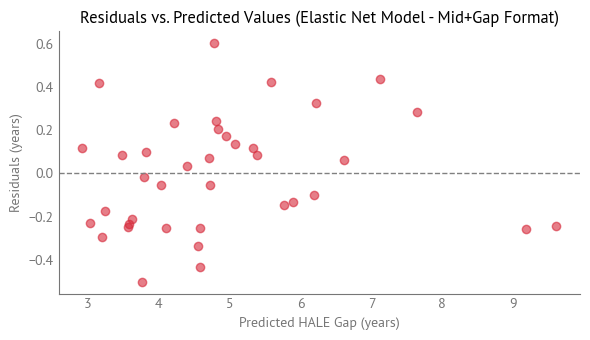

In [27]:
# Residual vs. Predicted values plot
plt.scatter(y_pred, residuals, color=AIBM_COLORS['crimson'], alpha=0.6)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
decorate(xlabel='Predicted HALE Gap (years)',
         ylabel='Residuals (years)',
         title='Residuals vs. Predicted Values (Elastic Net Model - Mid+Gap Format)')

plt.savefig('jb/figs/residuals_vs_predicted.png', dpi=300, bbox_inches='tight')

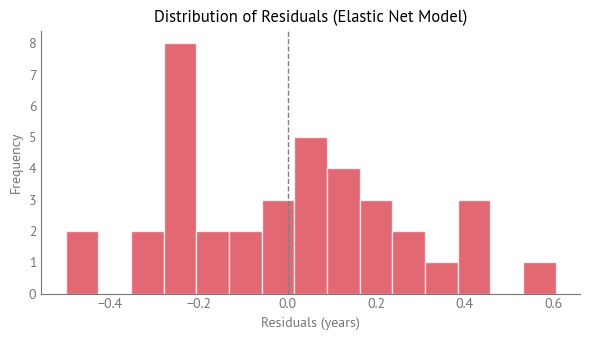

In [28]:
# Histogram of residuals
plt.hist(residuals, bins=15, color=AIBM_COLORS['crimson'], edgecolor='white', alpha=0.7)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
decorate(xlabel='Residuals (years)',
         ylabel='Frequency',
         title='Distribution of Residuals (Elastic Net Model)')

plt.savefig('jb/figs/residuals_distribution.png', dpi=300, bbox_inches='tight')

In [29]:
# Identify potential outliers (residuals > 2 standard deviations)
outlier_threshold = 2 * residuals.std()
outliers = residuals[abs(residuals) > outlier_threshold]

outlier_df = pd.DataFrame({
    'Country': outliers.index,
    'Actual_HALE_Gap': y[outliers.index],
    'Predicted_HALE_Gap': y_pred[outliers.index],
    'Residual': outliers.values,
    'Abs_Residual': abs(outliers.values)
}).sort_values('Abs_Residual', ascending=False)

outlier_df if not outlier_df.empty else "No outliers detected (|residual| > 2 std)"

,Country,Actual_HALE_Gap,Predicted_HALE_Gap,Residual,Abs_Residual
Country,,,,,
FRA,FRA,5.379232,4.774654,0.604578,0.604578


In [30]:
# Residuals by country (sorted by absolute residual)
residuals_by_country = pd.DataFrame({
    'Country': residuals.index,
    'Actual_HALE_Gap': y.values,
    'Predicted_HALE_Gap': y_pred,
    'Residual': residuals.values,
    'Abs_Residual': abs(residuals.values)
}).sort_values('Abs_Residual', ascending=False)

residuals_by_country.head(10)

,Country,Actual_HALE_Gap,Predicted_HALE_Gap,Residual,Abs_Residual
Country,,,,,
FRA,FRA,5.379232,4.774654,0.604578,0.604578
NZL,NZL,3.271057,3.771513,-0.500456,0.500456
POL,POL,7.554684,7.119098,0.435585,0.435585
BEL,BEL,4.153347,4.586752,-0.433406,0.433406
KOR,KOR,6.006658,5.582028,0.424630,0.424630
DNK,DNK,3.573784,3.155095,0.418689,0.418689
GRC,GRC,4.214505,4.552233,-0.337728,0.337728
HUN,HUN,6.541844,6.217318,0.324526,0.324526
NLD,NLD,2.914809,3.207465,-0.292656,0.292656


In [31]:
# Write residuals by country table to HTML
residuals_by_country_formatted = format_table_sig_figs(residuals_by_country)
residuals_by_country_formatted.to_html('jb/tables/residuals_by_country.html', index=False)

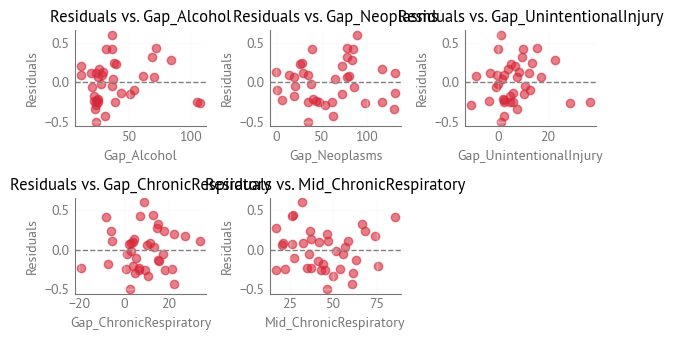

In [32]:
# Check for patterns: plot residuals vs. each predictor (top predictors by absolute coefficient)
# Get top predictors by absolute coefficient value
coef_abs = pd.Series(elastic_net_best_model.named_steps['elasticnet'].coef_, index=X.columns).abs()
top_predictors = coef_abs.nlargest(5).index.values

fig, axes = plt.subplots(2, 3)
axes = axes.flatten()

for i, pred in enumerate(top_predictors):
    if i < len(axes):
        axes[i].scatter(X[pred], residuals, color=AIBM_COLORS['crimson'], alpha=0.6)
        axes[i].axhline(y=0, color='gray', linestyle='--', linewidth=1)
        axes[i].set_xlabel(pred)
        axes[i].set_ylabel('Residuals')
        axes[i].set_title(f'Residuals vs. {pred}')
        axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(top_predictors), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('jb/figs/residuals_vs_predictors.png', dpi=300, bbox_inches='tight')

## Importance Analysis


In [33]:
# Create dictionary mapping predictor names to Elastic Net coefficients
# This makes it easier to look up coefficients by predictor name
elastic_net_coefs_dict = dict(zip(X.columns, elastic_net_best_model.named_steps['elasticnet'].coef_))

In [34]:
# Feature importance = |coefficient| × std(predictor)
# This measures the contribution of each predictor to the HALE gap variation
# Since predictors are standardized, we multiply by the original standard deviation
# to get importance on the original scale

predictor_importance = []

for predictor in X.columns:
    coef = elastic_net_coefs_dict.get(predictor, 0)
    
    # Get the original (unstandardized) standard deviation
    # The scaler was fit on X, so we can get the std from predictors DataFrame
    if predictor in predictors.columns:
        std_original = predictors[predictor].std()
        importance = abs(coef) * std_original
    else:
        std_original = 0
        importance = 0
    
    predictor_importance.append({
        'Predictor': predictor,
        'Coefficient': coef,
        'Std_Original': std_original,
        'Importance': importance
    })

importance_df = pd.DataFrame(predictor_importance).sort_values('Importance', ascending=False)
importance_df

,Predictor,Coefficient,Std_Original,Importance
0,Gap_Alcohol,0.790975,24.129152,19.085564
22,Gap_Neoplasms,0.325251,37.200265,12.099425
11,Mid_Cardiovascular,-0.065171,159.355803,10.385450
3,Mid_ChronicRespiratory,-0.155235,17.260494,2.679428
2,Gap_ChronicRespiratory,0.225111,10.475393,2.358122
4,Gap_UnintentionalInjury,0.247188,9.343600,2.309628
5,Mid_UnintentionalInjury,-0.110446,9.526374,1.052154
24,MaternalMortality_Female,0.079708,12.246133,0.976109
20,Gap_Suicide,0.148434,5.032198,0.746949
9,Mid_Diabetes,0.048907,10.290334,0.503270


In [35]:
# Write non-zero importance rows to HTML
importance_nonzero = importance_df[importance_df['Importance'] != 0].copy()
importance_nonzero_formatted = format_table_sig_figs(importance_nonzero)
importance_nonzero_formatted.to_html('jb/tables/predictor_importance.html', index=False)
importance_nonzero_formatted

,Predictor,Coefficient,Std_Original,Importance
0,Gap_Alcohol,0.7910,24.100,19.1000
22,Gap_Neoplasms,0.3250,37.200,12.1000
11,Mid_Cardiovascular,-0.0652,159.000,10.4000
3,Mid_ChronicRespiratory,-0.1550,17.300,2.6800
2,Gap_ChronicRespiratory,0.2250,10.500,2.3600
4,Gap_UnintentionalInjury,0.2470,9.340,2.3100
5,Mid_UnintentionalInjury,-0.1100,9.530,1.0500
24,MaternalMortality_Female,0.0797,12.200,0.9760
20,Gap_Suicide,0.1480,5.030,0.7470
9,Mid_Diabetes,0.0489,10.300,0.5030


### Visualize Predictor Importance

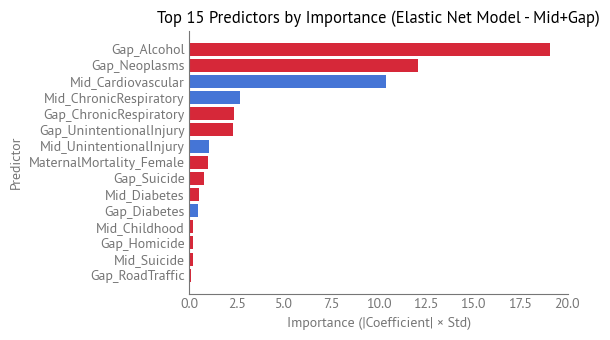

In [36]:
# Create bar chart of top predictors by importance
top_n = 15
top_importance = importance_df.head(top_n)

colors = [AIBM_COLORS['crimson'] if x > 0 else AIBM_COLORS['blue'] 
          for x in top_importance['Coefficient']]
plt.barh(range(len(top_importance)), top_importance['Importance'], color=colors)
plt.yticks(range(len(top_importance)), top_importance['Predictor'])
plt.gca().invert_yaxis()
decorate(xlabel='Importance (|Coefficient| × Std)',
         ylabel='Predictor',
         title=f'Top {top_n} Predictors by Importance (Elastic Net Model - Mid+Gap)')

plt.savefig('jb/figs/predictor_importance.png', dpi=300, bbox_inches='tight')

### Importance by Indicator

In [37]:
# Extract indicator names from Mid_ and Gap_ columns
all_indicators = set()
for col in predictors.columns:
    if col.startswith('Mid_'):
        indicator_name = col[4:]  # Remove 'Mid_' prefix
        all_indicators.add(indicator_name)
    elif col.startswith('Gap_'):
        indicator_name = col[4:]  # Remove 'Gap_' prefix
        all_indicators.add(indicator_name)

# Indicators with both Mid and Gap (most indicators)
mid_gap_indicators = sorted([ind for ind in all_indicators 
                             if f'Mid_{ind}' in predictors.columns and f'Gap_{ind}' in predictors.columns])

# Female-only indicators (e.g., MaternalMortality)
female_only_indicators = ['MaternalMortality']
female_only_indicators

['MaternalMortality']

In [38]:
# Aggregate importance by indicator (sum of Mid and Gap importance)
indicator_importance = {}

for indicator in mid_gap_indicators:
    mid_col = f'Mid_{indicator}'
    gap_col = f'Gap_{indicator}'
    
    mid_imp = importance_df[importance_df['Predictor'] == mid_col]['Importance'].values
    gap_imp = importance_df[importance_df['Predictor'] == gap_col]['Importance'].values
    
    if len(mid_imp) > 0 and len(gap_imp) > 0:
        total_importance = mid_imp[0] + gap_imp[0]
        indicator_importance[indicator] = {
            'Mid_Importance': mid_imp[0],
            'Gap_Importance': gap_imp[0],
            'Total_Importance': total_importance
        }

# Add female-only indicators (if any)
for indicator in female_only_indicators:
    # Check for any column matching this indicator
    matching_cols = [col for col in predictors.columns if indicator in col]
    print(matching_cols)
    if matching_cols:
        col = matching_cols[0]
        col_imp = importance_df[importance_df['Predictor'] == col]['Importance'].values
        if len(col_imp) > 0:
            indicator_importance[indicator] = {
                'Mid_Importance': np.nan,
                'Gap_Importance': np.nan,
                'Total_Importance': col_imp[0]
            }

indicator_importance_df = pd.DataFrame(indicator_importance).T
indicator_importance_df = indicator_importance_df.sort_values('Total_Importance', ascending=False)
indicator_importance_df

['MaternalMortality_Female']


,Mid_Importance,Gap_Importance,Total_Importance
Alcohol,0.000000,19.085564,19.085564
Neoplasms,0.000000,12.099425,12.099425
Cardiovascular,10.385450,0.000000,10.385450
ChronicRespiratory,2.679428,2.358122,5.037550
UnintentionalInjury,1.052154,2.309628,3.361782
MaternalMortality,NaN,NaN,0.976109
Suicide,0.202099,0.746949,0.949048
Diabetes,0.503270,0.444703,0.947973
Childhood,0.215679,0.041157,0.256836
Homicide,0.000000,0.204181,0.204181


In [39]:
# Write indicator importance table to HTML
indicator_importance_formatted = format_table_sig_figs(indicator_importance_df.reset_index())
indicator_importance_formatted = indicator_importance_formatted.rename(columns={'index': 'Indicator'})
indicator_importance_formatted.to_html('jb/tables/indicator_importance.html', index=False)
indicator_importance_formatted

,Indicator,Mid_Importance,Gap_Importance,Total_Importance
0,Alcohol,0.0000,19.1000,19.1000
1,Neoplasms,0.0000,12.1000,12.1000
2,Cardiovascular,10.4000,0.0000,10.4000
3,ChronicRespiratory,2.6800,2.3600,5.0400
4,UnintentionalInjury,1.0500,2.3100,3.3600
5,MaternalMortality,NaN,NaN,0.9760
6,Suicide,0.2020,0.7470,0.9490
7,Diabetes,0.5030,0.4450,0.9480
8,Childhood,0.2160,0.0412,0.2570
9,Homicide,0.0000,0.2040,0.2040


### Visualize Indicator Importance

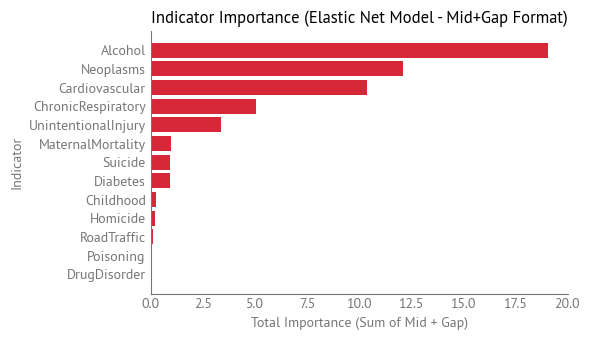

In [40]:
# Bar chart of indicator-level importance
colors_bar = [AIBM_COLORS['crimson'] for _ in range(len(indicator_importance_df))]
plt.barh(range(len(indicator_importance_df)), indicator_importance_df['Total_Importance'], 
         color=colors_bar)
plt.yticks(range(len(indicator_importance_df)), indicator_importance_df.index)
plt.gca().invert_yaxis()
decorate(xlabel='Total Importance (Sum of Mid + Gap)',
         ylabel='Indicator',
         title='Indicator Importance (Elastic Net Model - Mid+Gap Format)')

plt.savefig('jb/figs/indicator_importance.png', dpi=300, bbox_inches='tight')

## Statsmodels Linear Regression with Selected Predictors

In [41]:
import statsmodels.api as sm

# Extract predictors with non-zero coefficients from Elastic Net
elastic_net_coefs = elastic_net_best_model.named_steps['elasticnet'].coef_
non_zero_mask = elastic_net_coefs != 0
selected_predictors = X.columns[non_zero_mask].tolist()

print(f"Selected predictors (non-zero Elastic Net coefficients): {len(selected_predictors)}")
print(selected_predictors)

Selected predictors (non-zero Elastic Net coefficients): 17
['Gap_Alcohol', 'Gap_ChronicRespiratory', 'Mid_ChronicRespiratory', 'Gap_UnintentionalInjury', 'Mid_UnintentionalInjury', 'Gap_RoadTraffic', 'Gap_Diabetes', 'Mid_Diabetes', 'Mid_Cardiovascular', 'Gap_Childhood', 'Mid_Childhood', 'Gap_Homicide', 'Mid_Poisoning', 'Gap_Suicide', 'Mid_Suicide', 'Gap_Neoplasms', 'MaternalMortality_Female']


In [42]:
# Standardize the selected predictors to match Elastic Net preprocessing
# Create a new StandardScaler and fit it only on the selected predictors
# (We can't reuse the Elastic Net scaler because it was fit on all predictors)
from sklearn.preprocessing import StandardScaler

# Create subset of X with only selected predictors
X_selected = X[selected_predictors].copy()

# Create and fit a new scaler on the selected predictors only
ols_scaler = StandardScaler()
X_selected_standardized = pd.DataFrame(
    ols_scaler.fit_transform(X_selected),
    index=X_selected.index,
    columns=X_selected.columns
)

# Add constant term for intercept
X_selected_with_const = sm.add_constant(X_selected_standardized)

# Fit OLS regression on standardized predictors
ols_model = sm.OLS(y, X_selected_with_const).fit()

# Display summary
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     LifeExpectancy_gap   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     50.41
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           9.57e-13
Time:                        10:24:06   Log-Likelihood:               0.029019
No. Observations:                  38   AIC:                             35.94
Df Residuals:                      20   BIC:                             65.42
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        4.8975      0.054     90.586      0.000       4.785       5.010
Gap_Alcohol                  1.0419      0.201      5.181      0.000       0.622       1.461
Gap_ChronicRespiratory       0.2715      0.107      2.528      0.020       0.047       0.495
Mid_ChronicRespiratory      -0.1534      0.089     -1.725      0.100      -0.339       0.032
Gap_UnintentionalInjury      0.2163      0.147      1.467      0.158      -0.091       0.524
Mid_UnintentionalInjury     -0.1372      0.104     -1.324      0.200      -0.353       0.079
Gap_RoadTraffic              0.0117      0.125      0.094      0.926      -0.248       0.272
Gap_Diabetes                -0.1085      0.099     -1.092      0.288      -0.316       0.099
Mid_Diabetes                 0.0360      0.073      0.495      0.626      -0.116       0.188
Mid_Cardiovascular          -0.2560      0.156     -1.645      0.116      -0.581       0.069
Gap_Childhood               -0.0433      0.309     -0.140      0.890      -0.687       0.600
Mid_Childhood                0.1289      0.263      0.490      0.630      -0.420       0.678
Gap_Homicide                -0.0290      0.275     -0.106      0.917      -0.603       0.545
Mid_Poisoning                0.1356      0.142      0.953      0.352      -0.161       0.432
Gap_Suicide                  0.0006      0.300      0.002      0.998      -0.624       0.626
Mid_Suicide                  0.1004      0.176      0.570      0.575      -0.267       0.468
Gap_Neoplasms                0.3537      0.101      3.492      0.002       0.142       0.565
MaternalMortality_Female     0.1680      0.242      0.694      0.496      -0.337       0.673
==============================================================================
Omnibus:                        0.954   Durbin-Watson:                   1.924
Prob(Omnibus):                  0.621   Jarque-Bera (JB):                0.930
Skew:                           0.205   Prob(JB):                        0.628
Kurtosis:                       2.352   Cond. No.                         20.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
# Compare coefficients: Elastic Net vs OLS (both on standardized scale)
# Note: Both models now use standardized predictors, so coefficients are directly comparable
coef_comparison_selected = pd.DataFrame({
    'Predictor': selected_predictors,
    'ElasticNet_Coefficient': elastic_net_coefs[non_zero_mask],
    'OLS_Coefficient': ols_model.params[selected_predictors].values,
    'OLS_PValue': ols_model.pvalues[selected_predictors].values,
    'OLS_StdErr': ols_model.bse[selected_predictors].values
})

coef_comparison_selected['Difference'] = coef_comparison_selected['OLS_Coefficient'] - coef_comparison_selected['ElasticNet_Coefficient']
coef_comparison_selected = coef_comparison_selected.sort_values('ElasticNet_Coefficient', key=abs, ascending=False)
coef_comparison_selected

,Predictor,ElasticNet_Coefficient,OLS_Coefficient,OLS_PValue,OLS_StdErr,Difference
0,Gap_Alcohol,0.790975,1.041881,0.000045,0.201115,0.250905
15,Gap_Neoplasms,0.325251,0.353685,0.002297,0.101285,0.028434
3,Gap_UnintentionalInjury,0.247188,0.216337,0.157919,0.147467,-0.030851
1,Gap_ChronicRespiratory,0.225111,0.271461,0.019984,0.107367,0.046351
2,Mid_ChronicRespiratory,-0.155235,-0.153443,0.099956,0.088955,0.001792
13,Gap_Suicide,0.148434,0.000602,0.998416,0.299594,-0.147831
6,Gap_Diabetes,-0.134399,-0.108474,0.287723,0.099316,0.025925
4,Mid_UnintentionalInjury,-0.110446,-0.137187,0.200430,0.103614,-0.026741
16,MaternalMortality_Female,0.079708,0.167956,0.495508,0.241922,0.088248
9,Gap_Childhood,0.075702,-0.043255,0.889930,0.308594,-0.118956


In [44]:
# Write Elastic Net vs OLS coefficient comparison to HTML
coef_comparison_selected_formatted = format_table_sig_figs(coef_comparison_selected)
coef_comparison_selected_formatted.to_html('jb/tables/elasticnet_ols_coefficient_comparison.html', index=False)

In [45]:
# Compare model performance
ols_r2 = ols_model.rsquared
ols_adj_r2 = ols_model.rsquared_adj
ols_mae = mean_absolute_error(y, ols_model.fittedvalues)

performance_comparison = pd.DataFrame({
    'Model': ['Elastic Net', 'OLS (Selected Predictors)'],
    'R²': [r2_full, ols_r2],
    'Adjusted R²': [np.nan, ols_adj_r2],
    'MAE': [mean_absolute_error(y, y_pred), ols_mae],
    'Number of Predictors': [len(X.columns), len(selected_predictors)],
    'Non-Zero Coefficients': [np.sum(elastic_net_coefs != 0), len(selected_predictors)]
})

performance_comparison

,Model,R²,Adjusted R²,MAE,Number of Predictors,Non-Zero Coefficients
0,Elastic Net,0.973849,NaN,0.218712,25,17
1,OLS (Selected Predictors),0.977195,0.95781,0.199010,17,17


In [46]:
# Write performance comparison table to HTML
performance_comparison_formatted = format_table_sig_figs(performance_comparison)
performance_comparison_formatted.to_html('jb/tables/performance_comparison.html', index=False)

## Country-Level Predictions Comparison

In [47]:
# Generate predictions from both models
# Note: Both models use standardized predictors, so we need to standardize X for OLS predictions
elastic_net_predictions = elastic_net_best_model.predict(X)
ols_predictions = ols_model.predict(X_selected_with_const)  # Already standardized above

# Create comparison table
predictions_comparison = pd.DataFrame({
    'Country': y.index,
    'Actual_HALE_Gap': y.values,
    'ElasticNet_Prediction': elastic_net_predictions,
    'OLS_Prediction': ols_predictions,
    'EN_Residual': y.values - elastic_net_predictions,
    'OLS_Residual': y.values - ols_predictions,
    'Prediction_Difference': ols_predictions - elastic_net_predictions,
    'Abs_Prediction_Difference': np.abs(ols_predictions - elastic_net_predictions)
})

# Sort by absolute prediction difference to see where models disagree most
predictions_comparison = predictions_comparison.sort_values('Abs_Prediction_Difference', ascending=False)

predictions_comparison

,Country,Actual_HALE_Gap,ElasticNet_Prediction,OLS_Prediction,EN_Residual,OLS_Residual,Prediction_Difference,Abs_Prediction_Difference
Country,,,,,,,,
GRC,GRC,4.214505,4.552233,4.357078,-0.337728,-0.142573,-0.195156,0.195156
KOR,KOR,6.006658,5.582028,5.760986,0.424630,0.245672,0.178958,0.178958
MEX,MEX,6.090152,6.188156,6.353976,-0.098005,-0.263825,0.165820,0.165820
SWE,SWE,3.074617,3.248753,3.093690,-0.174135,-0.019073,-0.155063,0.155063
CZE,CZE,5.629791,5.773803,5.624402,-0.144012,0.005389,-0.149401,0.149401
POL,POL,7.554684,7.119098,7.259548,0.435585,0.295136,0.140450,0.140450
PRT,PRT,5.770625,5.900524,6.040515,-0.129899,-0.269890,0.139991,0.139991
ESP,ESP,5.122867,4.948270,5.081940,0.174597,0.040927,0.133670,0.133670
AUT,AUT,4.327479,4.578212,4.456520,-0.250733,-0.129041,-0.121692,0.121692


In [48]:
# Write predictions comparison table to HTML
predictions_comparison_formatted = format_table_sig_figs(predictions_comparison)
predictions_comparison_formatted.to_html('jb/tables/predictions_comparison.html', index=False)

In [49]:
# Summary statistics of prediction differences
print("Summary of Prediction Differences (OLS - Elastic Net):")
print("="*60)
print(f"Mean difference: {predictions_comparison['Prediction_Difference'].mean():.4f} years")
print(f"Median difference: {predictions_comparison['Prediction_Difference'].median():.4f} years")
print(f"Std deviation: {predictions_comparison['Prediction_Difference'].std():.4f} years")
print(f"Min difference: {predictions_comparison['Prediction_Difference'].min():.4f} years")
print(f"Max difference: {predictions_comparison['Prediction_Difference'].max():.4f} years")
print(f"Mean absolute difference: {predictions_comparison['Abs_Prediction_Difference'].mean():.4f} years")
print(f"\nCountries with largest prediction differences:")
predictions_comparison[['Country', 'Actual_HALE_Gap', 'ElasticNet_Prediction', 
                              'OLS_Prediction', 'Prediction_Difference']].head(10)

Summary of Prediction Differences (OLS - Elastic Net):
Mean difference: -0.0000 years
Median difference: -0.0289 years
Std deviation: 0.0939 years
Min difference: -0.1952 years
Max difference: 0.1790 years
Mean absolute difference: 0.0788 years

Countries with largest prediction differences:


,Country,Actual_HALE_Gap,ElasticNet_Prediction,OLS_Prediction,Prediction_Difference
Country,,,,,
GRC,GRC,4.214505,4.552233,4.357078,-0.195156
KOR,KOR,6.006658,5.582028,5.760986,0.178958
MEX,MEX,6.090152,6.188156,6.353976,0.165820
SWE,SWE,3.074617,3.248753,3.093690,-0.155063
CZE,CZE,5.629791,5.773803,5.624402,-0.149401
POL,POL,7.554684,7.119098,7.259548,0.140450
PRT,PRT,5.770625,5.900524,6.040515,0.139991
ESP,ESP,5.122867,4.948270,5.081940,0.133670
AUT,AUT,4.327479,4.578212,4.456520,-0.121692


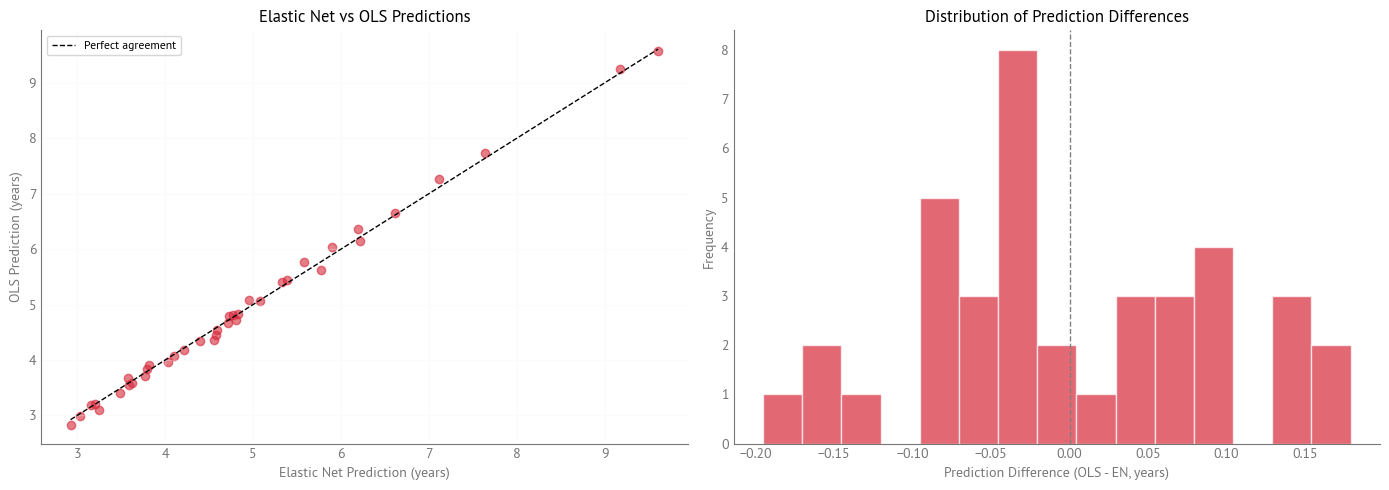

In [50]:
# Visualize prediction differences
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: EN vs OLS predictions
axes[0].scatter(elastic_net_predictions, ols_predictions, 
                color=AIBM_COLORS['crimson'], alpha=0.6)
axes[0].plot([elastic_net_predictions.min(), elastic_net_predictions.max()],
             [elastic_net_predictions.min(), elastic_net_predictions.max()],
             'k--', linewidth=1, label='Perfect agreement')
axes[0].set_xlabel('Elastic Net Prediction (years)')
axes[0].set_ylabel('OLS Prediction (years)')
axes[0].set_title('Elastic Net vs OLS Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of prediction differences
axes[1].hist(predictions_comparison['Prediction_Difference'], bins=15,
             color=AIBM_COLORS['crimson'], edgecolor='white', alpha=0.7)
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Prediction Difference (OLS - EN, years)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Prediction Differences')

plt.tight_layout()
plt.savefig('jb/figs/predictions_comparison.png', dpi=300, bbox_inches='tight')

In [51]:
# Compare residuals from both models
residuals_comparison = pd.DataFrame({
    'Country': y.index,
    'EN_Residual': y.values - elastic_net_predictions,
    'OLS_Residual': y.values - ols_predictions,
    'Residual_Difference': (y.values - ols_predictions) - (y.values - elastic_net_predictions)
})

residuals_comparison = residuals_comparison.sort_values('Residual_Difference', key=abs, ascending=False)
print("Residual Comparison (Actual - Predicted):")
print("="*60)
print(f"EN MAE: {mean_absolute_error(y, elastic_net_predictions):.4f} years")
print(f"OLS MAE: {mean_absolute_error(y, ols_predictions):.4f} years")
print(f"\nCountries with largest residual differences:")
residuals_comparison.head(10)

Residual Comparison (Actual - Predicted):
EN MAE: 0.2187 years
OLS MAE: 0.1990 years

Countries with largest residual differences:


,Country,EN_Residual,OLS_Residual,Residual_Difference
Country,,,,
GRC,GRC,-0.337728,-0.142573,0.195156
KOR,KOR,0.424630,0.245672,-0.178958
MEX,MEX,-0.098005,-0.263825,-0.165820
SWE,SWE,-0.174135,-0.019073,0.155063
CZE,CZE,-0.144012,0.005389,0.149401
POL,POL,0.435585,0.295136,-0.140450
PRT,PRT,-0.129899,-0.269890,-0.139991
ESP,ESP,0.174597,0.040927,-0.133670
AUT,AUT,-0.250733,-0.129041,0.121692
